In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
    encoding='latin-1')
df.sample(5)
df.shape

(5572, 5)

# data cleaning

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [6]:
df.sample(5)

,v1,v2
5503,ham,Perhaps * is much easy give your account ident...
4548,ham,"Haha, my friend tyler literally just asked if ..."
3632,ham,Hui xin is in da lib.
2460,ham,i cant talk to you now.i will call when i can....
1804,ham,The bus leaves at &lt;#&gt;


In [7]:
#rename 
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)


,target,text
2117,ham,Wish u many many returns of the day.. Happy bi...
4238,ham,"Sez, hows u & de arab boy? Hope u r all good g..."
5039,spam,Natalie (20/F) is inviting you to be her frien...
3682,ham,When did i use soc... I use it only at home......
2204,ham,Raji..pls do me a favour. Pls convey my Birthd...


In [8]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
print(df['target'])
df.head()

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: target, Length: 5572, dtype: int64


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# missing values
print("missing values ",df.isnull().sum())
# check for duplicate values
print("duplicate values ",df.duplicated(subset='text').sum())
# remove duplicates (we dont have duplicate values )
df = df.drop_duplicates(keep='first')
print("df",df)
print("after oprtn ",df.duplicated().sum())
df.shape

missing values  target    0
text      0
dtype: int64
duplicate values  403
df       target                                               text
0          0  Go until jurong point, crazy.. Available only ...
1          0                      Ok lar... Joking wif u oni...
2          1  Free entry in 2 a wkly comp to win FA Cup fina...
3          0  U dun say so early hor... U c already then say...
4          0  Nah I don't think he goes to usf, he lives aro...
...      ...                                                ...
5567       1  This is the 2nd time we have tried 2 contact u...
5568       0              Will Ì_ b going to esplanade fr home?
5569       0  Pity, * was in mood for that. So...any other s...
5570       0  The guy did some bitching but I acted like i'd...
5571       0                         Rofl. Its true to its name

[5169 rows x 2 columns]
after oprtn  0


(5169, 2)

# EDA

   target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...
target
0    4516
1     653
Name: count, dtype: int64


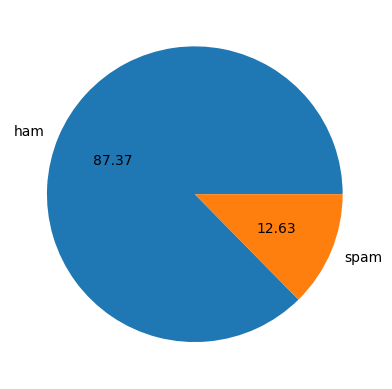

In [10]:
print(df.head())
print(df['target'].value_counts())
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()



🔹 Sample Data:
   target                                               text  num_characters  \
0       0  Go until jurong point, crazy.. Available only ...             111   
1       0                      Ok lar... Joking wif u oni...              29   
2       1  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3       0  U dun say so early hor... U c already then say...              49   
4       0  Nah I don't think he goes to usf, he lives aro...              61   

   num_words  num_sentences  
0         24              2  
1          8              2  
2         37              2  
3         13              1  
4         15              1  

 Overall Statistics:
       num_characters  num_words  num_sentences
count         5169.00    5169.00        5169.00
mean            78.98      18.46           1.97
std             58.24      13.32           1.45
min              2.00       1.00           1.00
25%             36.00       9.00           1.00
50%          

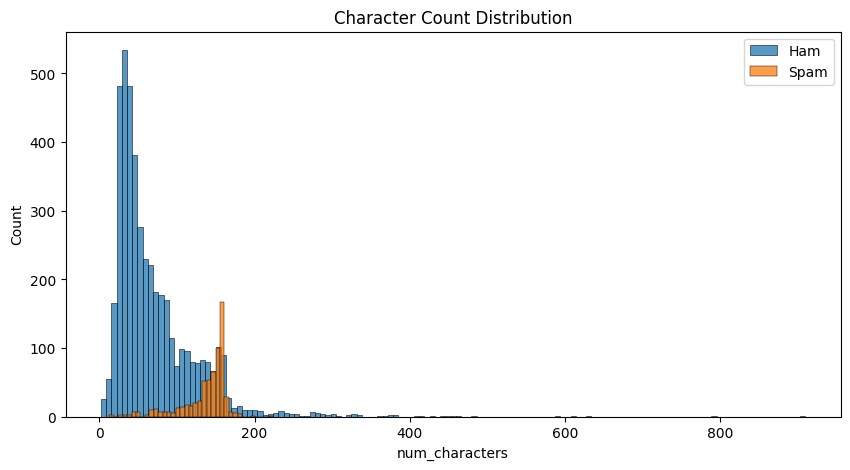

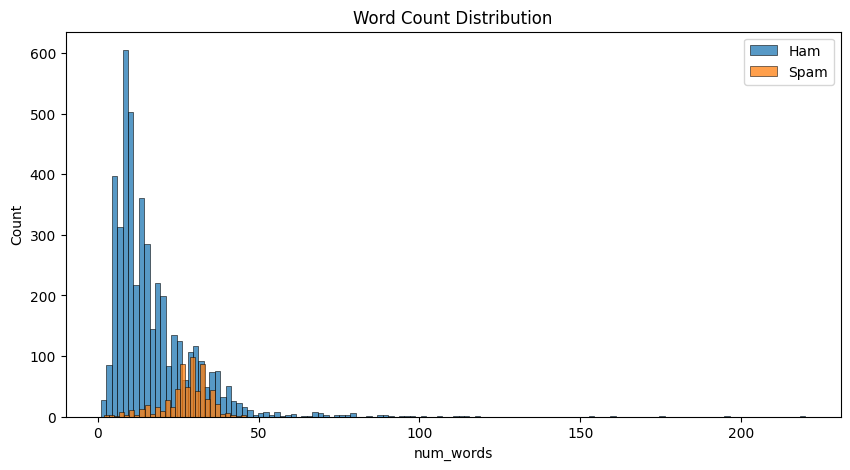

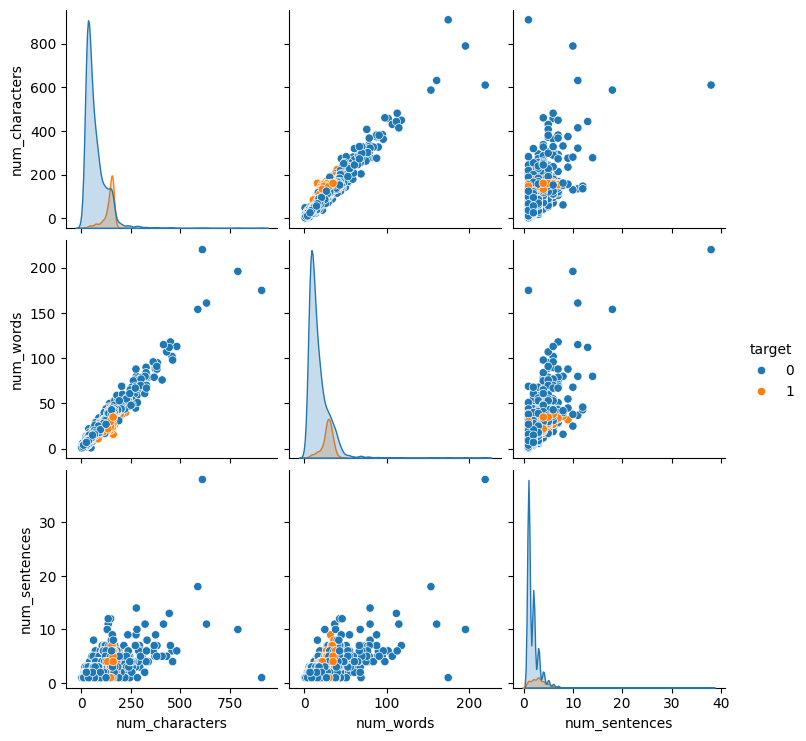

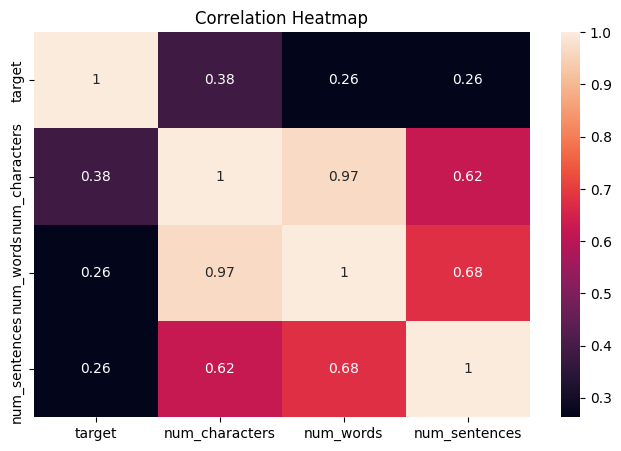

In [11]:
import nltk
import seaborn as sns
# ==============================
# Feature Engineering
# ==============================

df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

# ==============================
# Show Sample Data
# ==============================

print("\n🔹 Sample Data:")
print(df.head())

# ==============================
# Overall Statistics
# ==============================

print("\n Overall Statistics:")
print(df[['num_characters','num_words','num_sentences']].describe().round(2))

# ==============================
# Ham vs Spam Comparison
# ==============================

print("\n HAM Messages (0):")
print(df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe().round(2))

print("\nSPAM Messages (1):")
print(df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe().round(2))

# ==============================
# Visualizations
# ==============================

# Characters Distribution
plt.figure(figsize=(10,5))
sns.histplot(df[df['target'] == 0]['num_characters'], label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], label='Spam')
plt.legend()
plt.title("Character Count Distribution")
plt.show()

# Words Distribution
plt.figure(figsize=(10,5))
sns.histplot(df[df['target'] == 0]['num_words'], label='Ham')
sns.histplot(df[df['target'] == 1]['num_words'], label='Spam')
plt.legend()
plt.title("Word Count Distribution")
plt.show()

# Pairplot (relationships)
sns.pairplot(df[['num_characters','num_words','num_sentences','target']], hue='target')
plt.show()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Data preprocessing


* Lower case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



 Transformed Data Sample:
                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                    transformed_text  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


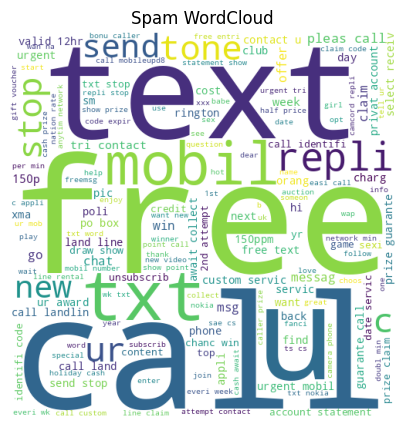

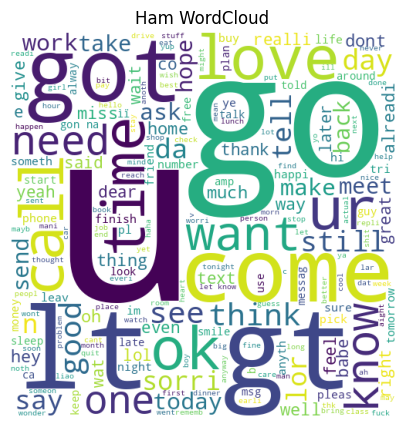

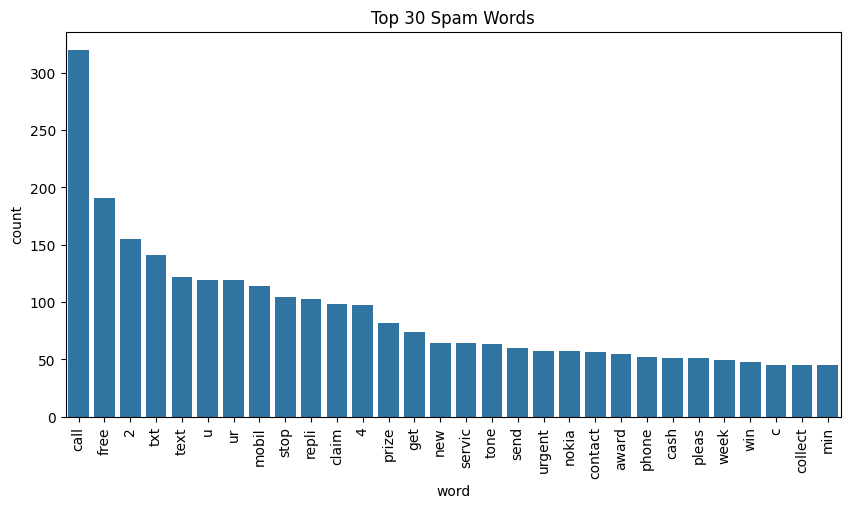

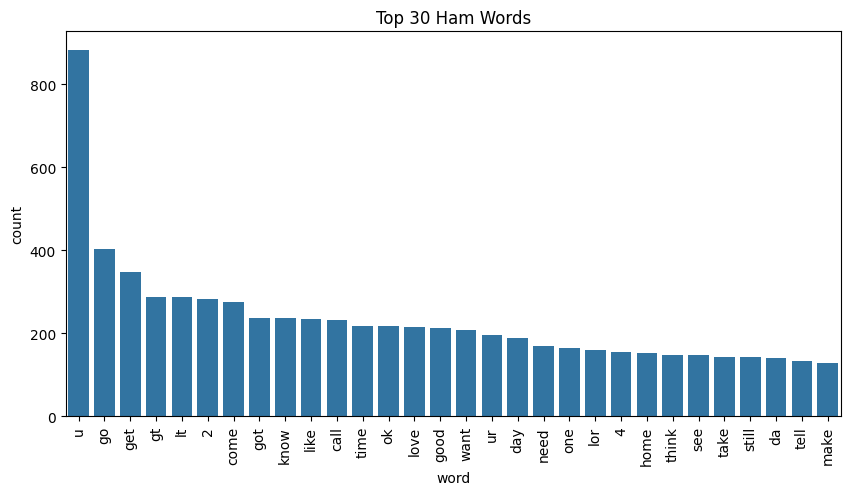

In [12]:

import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from collections import Counter

# download once
nltk.download('punkt')
nltk.download('stopwords')

# initialize stemmer
ps = PorterStemmer()

# ==============================
# Text Preprocessing Function
# ==============================

def transform_text(text):
    # lowercase
    text = text.lower()
    
    # tokenize
    words = nltk.word_tokenize(text)
    
    # remove non-alphanumeric
    words = [word for word in words if word.isalnum()]
    
    # remove stopwords & punctuation
    words = [word for word in words if word not in stopwords.words('english')]
    
    # stemming
    words = [ps.stem(word) for word in words]
    
    return " ".join(words)

# ==============================
# Apply Transformation
# ==============================

df['transformed_text'] = df['text'].apply(transform_text)

print("\n Transformed Data Sample:")
print(df[['text','transformed_text']].head())

# ==============================
# WordClouds
# ==============================

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

# Spam WordCloud
spam_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
spam_wc = wc.generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(spam_wc)
plt.title("Spam WordCloud")
plt.axis('off')
plt.show()

# Ham WordCloud
ham_text = df[df['target'] == 0]['transformed_text'].str.cat(sep=" ")
ham_wc = wc.generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(ham_wc)
plt.title("Ham WordCloud")
plt.axis('off')
plt.show()

# ==============================
#  Most Common Words (Spam)
# ==============================

spam_words = []
for msg in df[df['target'] == 1]['transformed_text']:
    spam_words.extend(msg.split())

spam_common = Counter(spam_words).most_common(30)
spam_df = pd.DataFrame(spam_common, columns=['word','count'])

plt.figure(figsize=(10,5))
sns.barplot(data=spam_df, x='word', y='count')
plt.xticks(rotation='vertical')
plt.title("Top 30 Spam Words")
plt.show()

# ==============================
# Most Common Words (Ham)
# ==============================

ham_words = []
for msg in df[df['target'] == 0]['transformed_text']:
    ham_words.extend(msg.split())

ham_common = Counter(ham_words).most_common(30)
ham_df = pd.DataFrame(ham_common, columns=['word','count'])

plt.figure(figsize=(10,5))
sns.barplot(data=ham_df, x='word', y='count')
plt.xticks(rotation='vertical')
plt.title("Top 30 Ham Words")
plt.show()

# Model Building

# Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

print("Shape of X:", X.shape)

Shape of X: (5169, 3000)


# Train-Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# Naive Bayes Comparison

In [15]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

models_nb = {
    "GaussianNB": GaussianNB(),
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB()
}

for name, model in models_nb.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


GaussianNB
Accuracy: 0.8733075435203095
Precision: 0.5159817351598174
Confusion Matrix:
 [[790 106]
 [ 25 113]]

MultinomialNB
Accuracy: 0.9709864603481625
Precision: 1.0
Confusion Matrix:
 [[896   0]
 [ 30 108]]

BernoulliNB
Accuracy: 0.9835589941972921
Precision: 0.991869918699187
Confusion Matrix:
 [[895   1]
 [ 16 122]]


# Multiple Model Comparison

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)
from xgboost import XGBClassifier

models = {
    "NB": MultinomialNB(),
    "LR": LogisticRegression(solver='liblinear'),
    "SVC": SVC(kernel='sigmoid', gamma=1.0),
    "DT": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(n_estimators=50, random_state=2),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=2),
    "Bagging": BaggingClassifier(n_estimators=50, random_state=2),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=50, random_state=2),
    "GBDT": GradientBoostingClassifier(n_estimators=50, random_state=2),
    "XGB": XGBClassifier(n_estimators=50, random_state=2)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    
    results.append([name, acc, prec])


NB
Accuracy: 0.9709864603481625
Precision: 1.0

LR
Accuracy: 0.9526112185686654
Precision: 0.978494623655914

SVC
Accuracy: 0.9758220502901354
Precision: 0.9747899159663865

DT
Accuracy: 0.9294003868471954
Precision: 0.8282828282828283

KNN
Accuracy: 0.9052224371373307
Precision: 1.0

RF
Accuracy: 0.97678916827853
Precision: 0.975

AdaBoost
Accuracy: 0.9235976789168279
Precision: 0.8390804597701149

Bagging
Accuracy: 0.9593810444874274
Precision: 0.8692307692307693

ExtraTrees
Accuracy: 0.9777562862669246
Precision: 0.967479674796748

GBDT
Accuracy: 0.9506769825918762
Precision: 0.9306930693069307

XGB
Accuracy: 0.9709864603481625
Precision: 0.95


# Results DataFrame

In [17]:
import pandas as pd

performance_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision'])
performance_df = performance_df.sort_values('Precision', ascending=False)

print(performance_df)

         Model  Accuracy  Precision
0           NB  0.970986   1.000000
4          KNN  0.905222   1.000000
1           LR  0.952611   0.978495
5           RF  0.976789   0.975000
2          SVC  0.975822   0.974790
8   ExtraTrees  0.977756   0.967480
10         XGB  0.970986   0.950000
9         GBDT  0.950677   0.930693
7      Bagging  0.959381   0.869231
6     AdaBoost  0.923598   0.839080
3           DT  0.929400   0.828283


# Visualization

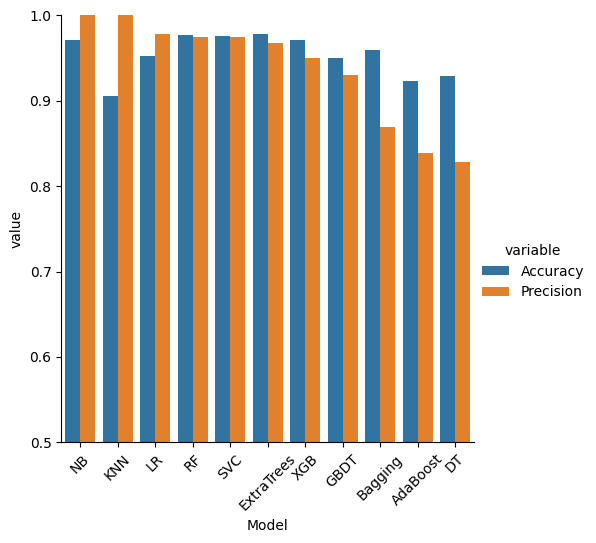

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(
    data=pd.melt(performance_df, id_vars="Model"),
    x="Model", y="value", hue="variable",
    kind="bar", height=5
)

plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.show()

# Voting Classifier

In [19]:
from sklearn.ensemble import VotingClassifier

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

voting = VotingClassifier(
    estimators=[('svm', svc), ('nb', mnb), ('et', etc)],
    voting='soft'
)

voting.fit(X_train, y_train)
y_pred = voting.predict(X_test)

print("Voting Accuracy:", accuracy_score(y_test, y_pred))
print("Voting Precision:", precision_score(y_test, y_pred))

Voting Accuracy: 0.9796905222437138
Voting Precision: 0.9834710743801653


# Stacking Classifier

In [20]:
from sklearn.ensemble import StackingClassifier

estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator
)

stacking.fit(X_train, y_train)
y_pred = stacking.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))
print("Stacking Precision:", precision_score(y_test, y_pred))

Stacking Accuracy: 0.9787234042553191
Stacking Precision: 0.9393939393939394


# Save Model

In [21]:
import pickle
from sklearn.naive_bayes import MultinomialNB

# Train model 
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

# ✅ Save trained objects
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

print("✅ Model trained and saved correctly!")

✅ Model trained and saved correctly!
